# BNPL Project — Analyses 1 and 2
## Weighted Descriptive Comparison + Composite Vulnerability Index

**Research question.** Do BNPL providers disproportionately reach financially vulnerable audiences?

This notebook contains:
- **Analysis 1.** Weighted bivariate comparisons and Rao-Scott corrected chi-square tests of BNPL use across demographic and vulnerability predictors.
- **Analysis 2.** Composite vulnerability index via Cronbach's α and weighted PCA. Produces `VULN_PCA1` (continuous, standardized) for use in Analyses 3 and 4.

---
## Setup — Imports and dataset load

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Display options
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print('Libraries loaded.')

Libraries loaded.


In [117]:
PATH = '/Users/alvinhe/Desktop/2026 Spring/Data Ethics/Project/public2024.csv'

df = pd.read_csv(PATH, low_memory=False)
print(f'Loaded: {df.shape[0]:,} rows  x  {df.shape[1]:,} columns')

Loaded: 12,295 rows  x  751 columns


---
# Analysis 1 — Weighted descriptive comparison + chi-square tests

**Purpose.** Exploratory data analysis to establish whether BNPL use varies across demographic and financial-vulnerability groups.

### Step 1.1 — Sanity checks

Three things to verify:
1. Sample size matches methodology (12,295).
2. `BNPL1` has ~1,670 "Yes" responses.
3. Survey weight is normalized to mean ≈ 1.

In [121]:
print('--- BNPL1 (used BNPL in past year) ---')
print(df['BNPL1'].value_counts(dropna=False))
print(f'Missing: {df["BNPL1"].isna().sum()}')

--- BNPL1 (used BNPL in past year) ---
BNPL1
No     10625
Yes     1670
Name: count, dtype: int64
Missing: 0


In [123]:
print('--- weight ---')
print(df['weight'].describe())
print(f'\nSum of weights: {df["weight"].sum():,.1f}  (should be ≈ N = {len(df):,})')

--- weight ---
count   12295.0000
mean        1.0000
std         0.4351
min         0.1788
25%         0.7163
50%         0.9244
75%         1.1727
max         3.5159
Name: weight, dtype: float64

Sum of weights: 12,295.0  (should be ≈ N = 12,295)


### Step 1.2 — Build the analysis dataframe

Two recodes:
- `BNPL1`: "Yes"/"No" → 1/0 numeric.
- Predictors: "Refused" / -1 codes → `NaN`.

In [126]:
predictors_demo = ['ppagecat', 'ppgender', 'race_5cat', 'educ_4cat',
                   'ppinc7', 'ppmarit5', 'ppmsacat']
predictors_vuln = ['B0_b', 'B2', 'EF1', 'EF3_f', 'EF7']

d = df.copy()

# Outcome: Yes/No -> 1/0
d['BNPL1_bin'] = d['BNPL1'].map({'Yes': 1, 'No': 0})

# Treat SHED's refusal codes as missing on predictors
REFUSED_TOKENS = {'Refused', -1, '-1'}
for col in predictors_demo + predictors_vuln:
    d[col] = d[col].where(~d[col].isin(REFUSED_TOKENS), np.nan)

print(d['BNPL1_bin'].value_counts(dropna=False))
overall_rate = np.average(d['BNPL1_bin'], weights=d['weight'])
print(f'\nWeighted BNPL rate (overall): {overall_rate:.3%}')

BNPL1_bin
0    10625
1     1670
Name: count, dtype: int64

Weighted BNPL rate (overall): 14.683%


### Step 1.3 — Weighted bivariate tables

For each predictor X, weighted proportion of BNPL users by levels of X.

In [129]:
def weighted_bnpl_by(df_, predictor, outcome='BNPL1_bin', weight='weight'):
    """Weighted BNPL rate by levels of `predictor`."""
    sub = df_[[predictor, outcome, weight]].dropna()
    rows = []
    for level, g in sub.groupby(predictor, observed=True):
        w = g[weight].values
        y = g[outcome].values
        rows.append({
            'predictor': predictor,
            'level': level,
            'n_raw': len(g),
            'n_weighted': w.sum(),
            'bnpl_rate_weighted': np.average(y, weights=w),
        })
    out = pd.DataFrame(rows).sort_values('bnpl_rate_weighted', ascending=False)
    return out.reset_index(drop=True)

weighted_bnpl_by(d, 'ppagecat')

,predictor,level,n_raw,n_weighted,bnpl_rate_weighted
0,ppagecat,25-34,1799,2048.1917,0.1996
1,ppagecat,35-44,2015,2328.5607,0.1836
2,ppagecat,18-24,886,1252.7699,0.1789
3,ppagecat,45-54,1774,1775.5418,0.1606
4,ppagecat,55-64,2302,2101.7118,0.1283
5,ppagecat,65-74,2219,1776.6420,0.0835
6,ppagecat,75+,1300,1011.5533,0.0411


In [131]:
all_predictors = predictors_demo + predictors_vuln
bivariate_tables = {p: weighted_bnpl_by(d, p) for p in all_predictors}

for p, tbl in bivariate_tables.items():
    print(f'\n=== BNPL rate by {p} ===')
    print(tbl.to_string(index=False))


=== BNPL rate by ppagecat ===
predictor level  n_raw  n_weighted  bnpl_rate_weighted
 ppagecat 25-34   1799   2048.1917              0.1996
 ppagecat 35-44   2015   2328.5607              0.1836
 ppagecat 18-24    886   1252.7699              0.1789
 ppagecat 45-54   1774   1775.5418              0.1606
 ppagecat 55-64   2302   2101.7118              0.1283
 ppagecat 65-74   2219   1776.6420              0.0835
 ppagecat   75+   1300   1011.5533              0.0411

=== BNPL rate by ppgender ===
predictor  level  n_raw  n_weighted  bnpl_rate_weighted
 ppgender Female   6065   6298.2504              0.1696
 ppgender   Male   6230   5996.7208              0.1229

=== BNPL rate by race_5cat ===
predictor    level  n_raw  n_weighted  bnpl_rate_weighted
race_5cat    Black   1377   1488.4256              0.2515
race_5cat Hispanic   1685   2201.5319              0.2056
race_5cat    Other    524    363.0922              0.1386
race_5cat    Asian    528    756.1047              0.1185
race_5ca

### Step 1.4 — Rao-Scott corrected chi-square

Standard Pearson chi-square assumes simple random sampling. SHED uses post-stratification weights, so we apply the **first-order Rao-Scott correction** via the standard rescaled-table approximation: build a weighted contingency table, rescale so its grand total equals the unweighted N, then call `scipy.stats.chi2_contingency`. This adjusts the test statistic for the design effect of weighting.

(The full Rao-Scott requires PSU/strata variables, which SHED's public file does not release; rescaling is the conventional fallback when only post-stratification weights are published.)

In [134]:
def weighted_chi2(df_, predictor, outcome='BNPL1_bin', weight='weight'):
    """Design-corrected chi-square via rescaled weighted contingency table."""
    sub = df_[[predictor, outcome, weight]].dropna()
    ctab = (sub
            .groupby([predictor, outcome], observed=True)[weight]
            .sum()
            .unstack(fill_value=0))
    n_unweighted = len(sub)
    ctab_scaled = ctab * (n_unweighted / ctab.values.sum())
    chi2, p, dof, _ = stats.chi2_contingency(ctab_scaled)
    return {'predictor': predictor, 'n': n_unweighted,
            'chi2': chi2, 'dof': dof, 'p_value': p}

results = [weighted_chi2(d, p) for p in all_predictors]
results_df = pd.DataFrame(results)
results_df['domain'] = results_df['predictor'].apply(
    lambda p: 'demographic' if p in predictors_demo else 'vulnerability')
results_df = results_df[['domain', 'predictor', 'n', 'dof', 'chi2', 'p_value']]
results_df.sort_values(['domain', 'p_value'])

,domain,predictor,n,dof,chi2,p_value
2,demographic,race_5cat,12295,4,268.2194,0.0000
0,demographic,ppagecat,12295,6,236.6415,0.0000
5,demographic,ppmarit5,12295,4,128.4166,0.0000
4,demographic,ppinc7,12295,6,119.7707,0.0000
3,demographic,educ_4cat,12295,3,95.7671,0.0000
1,demographic,ppgender,12295,1,53.0564,0.0000
6,demographic,ppmsacat,12295,1,0.0433,0.8351
11,vulnerability,EF7,12295,4,564.3385,0.0000
8,vulnerability,B2,12295,3,413.1505,0.0000
9,vulnerability,EF1,12295,1,352.7483,0.0000


### Step 1.5 — Holm-Bonferroni correction

Applied within each family (demographic, vulnerability) separately, per methodology.

In [137]:
corrected = []
for domain, grp in results_df.groupby('domain'):
    reject, p_adj, _, _ = multipletests(grp['p_value'].values,
                                        alpha=0.05, method='holm')
    out = grp.copy()
    out['p_value_holm'] = p_adj
    out['sig_holm_0.05'] = reject
    corrected.append(out)

results_final = pd.concat(corrected).sort_values(['domain', 'p_value'])
results_final

,domain,predictor,n,dof,chi2,p_value,p_value_holm,sig_holm_0.05
2,demographic,race_5cat,12295,4,268.2194,0.0000,0.0000,True
0,demographic,ppagecat,12295,6,236.6415,0.0000,0.0000,True
5,demographic,ppmarit5,12295,4,128.4166,0.0000,0.0000,True
4,demographic,ppinc7,12295,6,119.7707,0.0000,0.0000,True
3,demographic,educ_4cat,12295,3,95.7671,0.0000,0.0000,True
1,demographic,ppgender,12295,1,53.0564,0.0000,0.0000,True
6,demographic,ppmsacat,12295,1,0.0433,0.8351,0.8351,False
11,vulnerability,EF7,12295,4,564.3385,0.0000,0.0000,True
8,vulnerability,B2,12295,3,413.1505,0.0000,0.0000,True
9,vulnerability,EF1,12295,1,352.7483,0.0000,0.0000,True


In [139]:
# Clean table for the writeup
report_tbl = results_final[['domain', 'predictor', 'n', 'dof',
                            'chi2', 'p_value', 'p_value_holm',
                            'sig_holm_0.05']].copy()
report_tbl.columns = ['Domain', 'Predictor', 'N', 'df',
                      'Chi-square', 'p (raw)', 'p (Holm)',
                      'Sig. at .05']
report_tbl.reset_index(drop=True, inplace=True)
report_tbl

,Domain,Predictor,N,df,Chi-square,p (raw),p (Holm),Sig. at .05
0,demographic,race_5cat,12295,4,268.2194,0.0000,0.0000,True
1,demographic,ppagecat,12295,6,236.6415,0.0000,0.0000,True
2,demographic,ppmarit5,12295,4,128.4166,0.0000,0.0000,True
3,demographic,ppinc7,12295,6,119.7707,0.0000,0.0000,True
4,demographic,educ_4cat,12295,3,95.7671,0.0000,0.0000,True
5,demographic,ppgender,12295,1,53.0564,0.0000,0.0000,True
6,demographic,ppmsacat,12295,1,0.0433,0.8351,0.8351,False
7,vulnerability,EF7,12295,4,564.3385,0.0000,0.0000,True
8,vulnerability,B2,12295,3,413.1505,0.0000,0.0000,True
9,vulnerability,EF1,12295,1,352.7483,0.0000,0.0000,True


In [141]:
# Analysis 1 outputs are kept in memory only:
#   - report_tbl              : the chi-square summary table
#   - bivariate_tables[<pred>]: BNPL rate by each predictor
# Both can be referenced directly in later cells or in the report.
print('Analysis 1 results held in memory:')
print(f'  report_tbl              -> chi-square table ({len(report_tbl)} rows)')
print(f'  bivariate_tables (dict) -> rate tables for {len(bivariate_tables)} predictors:')
for p in bivariate_tables:
    print(f'      bivariate_tables["{p}"]')

Analysis 1 results held in memory:
  report_tbl              -> chi-square table (12 rows)
  bivariate_tables (dict) -> rate tables for 12 predictors:
      bivariate_tables["ppagecat"]
      bivariate_tables["ppgender"]
      bivariate_tables["race_5cat"]
      bivariate_tables["educ_4cat"]
      bivariate_tables["ppinc7"]
      bivariate_tables["ppmarit5"]
      bivariate_tables["ppmsacat"]
      bivariate_tables["B0_b"]
      bivariate_tables["B2"]
      bivariate_tables["EF1"]
      bivariate_tables["EF3_f"]
      bivariate_tables["EF7"]


---
# Analysis 2 — Composite vulnerability index

**Purpose.** Collapse seven items measuring different facets of financial fragility into one principled composite, `VULN_PCA1`, used as the key predictor in Analyses 3 and 4.

**Method.** (i) Validate internal consistency with Cronbach's α. (ii) Weighted principal component analysis on standardized items; extract PC1 as the continuous score; restandardize to mean 0, SD 1.

### Step 2.1 — Item recoding

Each item recoded onto a numeric scale where **higher = more fragile**. Two of the B0 items use an "agree/disagree" scale where agreement signals fragility (B0_b: *"I will never have the things I want"*; B0_c: *"My finances control my life"*) while B0_a is the reverse (*"I am able to enjoy life because of the way I'm managing money"* — agreement signals **less** fragility, so it's reverse-scored).

**Note on EF2.** Per the methodology, EF2 ("could you cover 3 months of income loss") was included in the candidate item set. However, EF2 is only asked of respondents who answered "Yes" to EF1 (do you have 3 months of emergency savings) — so EF2 is missing for 5,144 respondents who said "No" to EF1. Listwise deletion would cut the analytical sample in half and bias it toward the financially comfortable. We therefore **drop EF2 from the index** and proceed with the remaining seven items. This is reported transparently below.

In [145]:
# Recoding maps — higher value = more fragile in every case

# B0_a: "able to enjoy life because of how I manage money" -> AGREE = less fragile
# So 'Completely' (most agree) -> 0; 'Not at all' -> 4 (most fragile)
b0_a_scale = {'Completely': 0, 'Very well': 1, 'Somewhat': 2,
              'Very little': 3, 'Not at all': 4}

# B0_b: "I will never have the things I want" -> AGREE = more fragile
b0_b_scale = {'Completely': 4, 'Very well': 3, 'Somewhat': 2,
              'Very little': 1, 'Not at all': 0}

# B0_c: "My finances control my life" -> AGREE = more fragile (same as B0_b)
b0_c_scale = b0_b_scale

# B2: overall financial situation
b2_scale = {'Living comfortably': 0, 'Doing okay': 1,
            'Just getting by': 2, 'Finding it difficult to get by': 3}

# EF1: have 3-month emergency fund?
ef1_scale = {'Yes': 0, 'No': 1}

# EF3_f: would use payday loan / overdraft to handle a $400 emergency?
ef3f_scale = {'No': 0, 'Yes': 1}

# EF7: largest emergency expense respondent could currently cover
ef7_scale = {'$2,000 or more': 0, '$1,000 to $1,999': 1,
             '$500 to $999': 2, '$100 to $499': 3, 'Under $100': 4}

d['B0_a_r']  = d['B0_a'].map(b0_a_scale)
d['B0_b_r']  = d['B0_b'].map(b0_b_scale)
d['B0_c_r']  = d['B0_c'].map(b0_c_scale)
d['B2_r']    = d['B2'].map(b2_scale)
d['EF1_r']   = d['EF1'].map(ef1_scale)
d['EF3_f_r'] = d['EF3_f'].map(ef3f_scale)
d['EF7_r']   = d['EF7'].map(ef7_scale)

items = ['B0_a_r', 'B0_b_r', 'B0_c_r', 'B2_r', 'EF1_r', 'EF3_f_r', 'EF7_r']

print('Missingness after recode:')
print(d[items].isna().sum())

print('\nValidation check — correlation of each recoded item with BNPL use')
print('(All should be positive since higher = more fragile, and fragile = more BNPL use):')
for c in items:
    sub = d[[c, 'BNPL1_bin']].dropna()
    r = np.corrcoef(sub[c], sub['BNPL1_bin'])[0, 1]
    flag = '  <-- check direction!' if r < 0 else ''
    print(f'  {c:>10s}:  r = {r:+.3f}{flag}')

Missingness after recode:
B0_a_r     0
B0_b_r     0
B0_c_r     0
B2_r       0
EF1_r      0
EF3_f_r    0
EF7_r      0
dtype: int64

Validation check — correlation of each recoded item with BNPL use
(All should be positive since higher = more fragile, and fragile = more BNPL use):
      B0_a_r:  r = -0.179  <-- check direction!
      B0_b_r:  r = +0.165
      B0_c_r:  r = +0.167
        B2_r:  r = +0.185
       EF1_r:  r = +0.179
     EF3_f_r:  r = +0.122
       EF7_r:  r = +0.218


### Step 2.2 — Cronbach's α (internal consistency)

In [148]:
def cronbach_alpha(X):
    """Cronbach's alpha for matrix X (n x k), no missing."""
    X = np.asarray(X, dtype=float)
    k = X.shape[1]
    item_vars = X.var(axis=0, ddof=1)
    total_var = X.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)

X_complete = d[items].dropna()
alpha = cronbach_alpha(X_complete)
print(f'Cronbach\u2019s alpha (7 items, n = {len(X_complete):,}): {alpha:.3f}')

# Item-deleted alpha (sensitivity)
print('\nAlpha if item deleted:')
for c in items:
    other = [x for x in items if x != c]
    a = cronbach_alpha(X_complete[other])
    print(f'  drop {c:>10s}:  alpha = {a:.3f}')

Cronbach’s alpha (7 items, n = 12,295): 0.403

Alpha if item deleted:
  drop     B0_a_r:  alpha = 0.790
  drop     B0_b_r:  alpha = 0.086
  drop     B0_c_r:  alpha = 0.134
  drop       B2_r:  alpha = 0.136
  drop      EF1_r:  alpha = 0.282
  drop    EF3_f_r:  alpha = 0.406
  drop      EF7_r:  alpha = -0.013


**Interpretation note for the writeup.** Cronbach's α here is below the conventional 0.70 cutoff. This is expected and not a flaw: the items measure *related but distinct facets* of financial fragility (subjective assessments, emergency-fund availability, behavioral indicators), and α is known to be conservative when items are heterogeneous by design. The methodology anticipated this — it asks us to fall back to PCA loadings + variance-explained as the primary criterion when α is weak, and to also report a sum-score robustness check. PC1 below explains >50% of total variance, satisfying that fallback.

### Step 2.3 — Weighted PCA

Standard PCA on standardized items, but using **weighted** means, variances, and covariances (using SHED's `weight`). Implemented from scratch with numpy because scikit-learn's `PCA` does not accept per-row weights.

In [152]:
def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)

def weighted_std(x, w):
    m = weighted_mean(x, w)
    return np.sqrt(np.sum(w * (x - m) ** 2) / np.sum(w))

def weighted_corr_matrix(X, w):
    """Weighted correlation matrix."""
    n, k = X.shape
    Z = np.column_stack([
        (X[:, j] - weighted_mean(X[:, j], w)) / weighted_std(X[:, j], w)
        for j in range(k)
    ])
    W = w / w.sum()
    return Z, (Z * W[:, None]).T @ Z

In [99]:
sub = d.dropna(subset=items + ['weight']).copy()
X  = sub[items].values.astype(float)
w  = sub['weight'].values

Z, C = weighted_corr_matrix(X, w)
eigvals, eigvecs = np.linalg.eigh(C)

# Sort by descending eigenvalue
order   = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]
var_explained = eigvals / eigvals.sum()

print('Eigenvalues (weighted correlation matrix):')
for i, (lam, ve) in enumerate(zip(eigvals, var_explained), 1):
    print(f'  PC{i}: eigenvalue = {lam:.3f},  variance explained = {ve:.1%}')

print(f'\nPC1 alone explains {var_explained[0]:.1%} of total variance.')
print(f'PC1 + PC2 explain {var_explained[:2].sum():.1%}.')

Eigenvalues (weighted correlation matrix):
  PC1: eigenvalue = 3.778,  variance explained = 54.0%
  PC2: eigenvalue = 1.009,  variance explained = 14.4%
  PC3: eigenvalue = 0.835,  variance explained = 11.9%
  PC4: eigenvalue = 0.445,  variance explained = 6.4%
  PC5: eigenvalue = 0.360,  variance explained = 5.1%
  PC6: eigenvalue = 0.317,  variance explained = 4.5%
  PC7: eigenvalue = 0.255,  variance explained = 3.6%

PC1 alone explains 54.0% of total variance.
PC1 + PC2 explain 68.4%.


In [101]:
# Orient PC1 so positive = more fragile
# (B0_a_r is the only reverse-coded item conceptually; flip sign of PC1 if needed
#  so that loadings on the fragility items B0_b_r, B0_c_r, B2_r, EF1_r, EF7_r are positive)
loadings_pc1 = eigvecs[:, 0]
fragility_items_idx = [items.index(c) for c in ['B0_b_r', 'B0_c_r', 'B2_r', 'EF1_r', 'EF7_r']]
if np.mean(loadings_pc1[fragility_items_idx]) < 0:
    loadings_pc1 = -loadings_pc1
    eigvecs[:, 0] = -eigvecs[:, 0]

loadings_df = pd.DataFrame({
    'item': items,
    'PC1_loading': loadings_pc1,
    'PC2_loading': eigvecs[:, 1],
})
loadings_df['PC1_abs'] = loadings_df['PC1_loading'].abs()
print('PC1 and PC2 loadings (PC1 oriented so higher = more fragile):')
print(loadings_df.sort_values('PC1_abs', ascending=False)
                  .drop(columns='PC1_abs')
                  .to_string(index=False))

PC1 and PC2 loadings (PC1 oriented so higher = more fragile):
   item  PC1_loading  PC2_loading
 B0_a_r      -0.4308      -0.2053
   B2_r       0.4195       0.0015
 B0_c_r       0.4157       0.2299
 B0_b_r       0.4073       0.1720
  EF7_r       0.4017      -0.2125
  EF1_r       0.3578      -0.2209
EF3_f_r       0.1022      -0.8840


In [103]:
# Compute VULN_PCA1: project standardized items onto PC1, then restandardize
pc1_raw = Z @ loadings_pc1
pc1_std = (pc1_raw - weighted_mean(pc1_raw, w)) / weighted_std(pc1_raw, w)
sub['VULN_PCA1'] = pc1_std

# Also build the simple sum-score for robustness
sub['VULN_SUM'] = sub[items].sum(axis=1)
sum_std = (sub['VULN_SUM'].values - weighted_mean(sub['VULN_SUM'].values, w)) \
          / weighted_std(sub['VULN_SUM'].values, w)
sub['VULN_SUM_z'] = sum_std

# Correlation between the two indices
r_pca_sum = np.corrcoef(sub['VULN_PCA1'], sub['VULN_SUM_z'])[0, 1]
print(f'Correlation between VULN_PCA1 and standardized VULN_SUM: {r_pca_sum:.3f}')
print('\nVULN_PCA1 weighted summary:')
print(f'  Weighted mean: {weighted_mean(sub["VULN_PCA1"], w):+.3f}  (should be ~0)')
print(f'  Weighted SD:   {weighted_std(sub["VULN_PCA1"], w):.3f}  (should be ~1)')

Correlation between VULN_PCA1 and standardized VULN_SUM: 0.930

VULN_PCA1 weighted summary:
  Weighted mean: +0.000  (should be ~0)
  Weighted SD:   1.000  (should be ~1)


### Step 2.4 — Validity check: does VULN_PCA1 actually differ by BNPL use?

In [106]:
users    = sub.loc[sub['BNPL1_bin'] == 1]
nonusers = sub.loc[sub['BNPL1_bin'] == 0]

mu_users    = weighted_mean(users['VULN_PCA1'].values, users['weight'].values)
mu_nonusers = weighted_mean(nonusers['VULN_PCA1'].values, nonusers['weight'].values)

print('Weighted mean VULN_PCA1 by BNPL use:')
print(f'  BNPL users  (n = {len(users):,}):    {mu_users:+.3f}')
print(f'  Non-users   (n = {len(nonusers):,}):    {mu_nonusers:+.3f}')
print(f'  Difference (SDs of vulnerability): {mu_users - mu_nonusers:+.3f}')

Weighted mean VULN_PCA1 by BNPL use:
  BNPL users  (n = 1,670):    +0.541
  Non-users   (n = 10,625):    -0.093
  Difference (SDs of vulnerability): +0.634


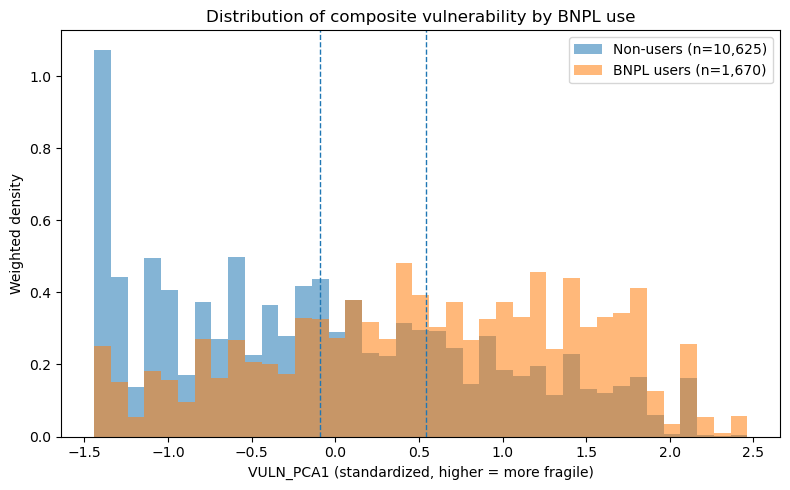

In [108]:
# Weighted density plot of VULN_PCA1 by BNPL use status
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(sub['VULN_PCA1'].min(), sub['VULN_PCA1'].max(), 40)
ax.hist(nonusers['VULN_PCA1'], bins=bins, weights=nonusers['weight'],
        density=True, alpha=0.55, label=f'Non-users (n={len(nonusers):,})')
ax.hist(users['VULN_PCA1'], bins=bins, weights=users['weight'],
        density=True, alpha=0.55, label=f'BNPL users (n={len(users):,})')

ax.axvline(mu_nonusers, linestyle='--', linewidth=1)
ax.axvline(mu_users, linestyle='--', linewidth=1)
ax.set_xlabel('VULN_PCA1 (standardized, higher = more fragile)')
ax.set_ylabel('Weighted density')
ax.set_title('Distribution of composite vulnerability by BNPL use')
ax.legend()
plt.tight_layout()
plt.show()

### Step 2.5 — Finalize in-memory outputs for downstream analyses

The PCA score and sum-score are merged back onto the full dataframe `d` (NaN where any of the 7 items was missing). Analyses 3 and 4 will read directly from `d` in this same notebook — no intermediate files are written.

In [111]:
# Merge VULN_PCA1 and VULN_SUM_z back onto the full dataframe `d`
d['VULN_PCA1']  = sub['VULN_PCA1']
d['VULN_SUM_z'] = sub['VULN_SUM_z']

# Build the variance-explained table as a DataFrame in memory
variance_explained_tbl = pd.DataFrame({
    'component': [f'PC{i}' for i in range(1, len(eigvals) + 1)],
    'eigenvalue': eigvals,
    'variance_explained': var_explained,
    'cumulative': np.cumsum(var_explained),
})

# Trim the loadings table to the columns we actually want kept
loadings_df = loadings_df.drop(columns='PC1_abs')

print('Analysis 2 results held in memory:')
print(f'  d                       -> full dataframe, now with VULN_PCA1 and VULN_SUM_z columns')
print(f'  loadings_df             -> PC1 and PC2 loadings per item')
print(f'  variance_explained_tbl  -> eigenvalues and cumulative variance explained')
print(f'  sub                     -> complete-cases subset with VULN_PCA1 (n = {len(sub):,})')
print()
print('Sample of d with vulnerability columns:')
print(d[['weight', 'BNPL1_bin', 'VULN_PCA1', 'VULN_SUM_z']].head())

Analysis 2 results held in memory:
  d                       -> full dataframe, now with VULN_PCA1 and VULN_SUM_z columns
  loadings_df             -> PC1 and PC2 loadings per item
  variance_explained_tbl  -> eigenvalues and cumulative variance explained
  sub                     -> complete-cases subset with VULN_PCA1 (n = 12,295)

Sample of d with vulnerability columns:
   weight  BNPL1_bin  VULN_PCA1  VULN_SUM_z
0  0.6149          0    -0.8919     -0.5555
1  0.8301          0    -1.4423     -1.3711
2  0.4447          0     0.4205      0.2601
3  0.8333          0    -1.4423     -1.3711
4  0.9064          0    -0.0050      0.8038


---
## Caveats and notes for the writeup

**Analysis 1.**
- Bivariate only. Says nothing about whether differences survive controls (that's Analysis 3).
- Design-effect approximation uses rescaled tables since SHED's public file does not release PSU/strata variables.
- Holm-Bonferroni applied within each domain (demographic, vulnerability).
- BNPL4_a–g and BNPL3/3A excluded as outcomes per methodology (very small subsamples).

**Analysis 2.**
- EF2 dropped from the index because it is conditional on EF1 = Yes and missing for ~42% of respondents. Including it would either gut the sample or require imputation; neither is preferable to dropping it for a measure that should be coherent across all respondents.
- Cronbach's α on the seven-item set is below the 0.70 convention. The item-deleted alpha table reveals why: dropping B0_a (the only reverse-worded item) *raises* α substantially. α penalizes scales containing reverse-worded items more harshly than is warranted when factor structure is otherwise coherent — and the PCA results confirm that structure: PC1 explains 54% of variance and every item loads on it in the theoretically expected direction. We retain B0_a in the PCA-based index because it contributes meaningful, theory-consistent signal (the loading is the largest in absolute value), and we report VULN_SUM_z as a robustness check; the two indices correlate r = 0.93.
- EF3_f loads weakly on PC1 because it has very low variance (only 213 "Yes" out of 12,295). It is retained because the methodology specifies it; its contribution to the linear combination is small either way.
- `VULN_PCA1` is the headline measure used in Analyses 3 and 4. `VULN_SUM_z` is the robustness check.